# LIBRARY

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# MODULE 0:  EXPLORATION

In [117]:
file_path = "../1.DATASET/cmi_internet.csv"
df=pd.read_csv(file_path)
df.head(3)

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,...,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0


In [118]:
df.shape

(8460, 82)

## Info from columns

### general

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Enroll_Season               8460 non-null   object 
 2   Basic_Demos-Age                         8460 non-null   int64  
 3   Basic_Demos-Sex                         8460 non-null   int64  
 4   CGAS-Season                             7158 non-null   object 
 5   CGAS-CGAS_Score                         7034 non-null   float64
 6   Physical-Season                         7858 non-null   object 
 7   Physical-BMI                            7591 non-null   float64
 8   Physical-Height                         7595 non-null   float64
 9   Physical-Weight                         7641 non-null   float64
 10  Physical-Waist_Circumference            5624 non-null   floa

In [120]:
for name in df.columns:
    print(name, df[name].isnull().sum())

id 0
Basic_Demos-Enroll_Season 0
Basic_Demos-Age 0
Basic_Demos-Sex 0
CGAS-Season 1302
CGAS-CGAS_Score 1426
Physical-Season 602
Physical-BMI 869
Physical-Height 865
Physical-Weight 819
Physical-Waist_Circumference 2836
Physical-Diastolic_BP 932
Physical-HeartRate 921
Physical-Systolic_BP 932
Fitness_Endurance-Season 2456
Fitness_Endurance-Max_Stage 2980
Fitness_Endurance-Time_Mins 2982
Fitness_Endurance-Time_Sec 2982
FGC-Season 569
FGC-FGC_CU 1517
FGC-FGC_CU_Zone 1554
FGC-FGC_GSND 2673
FGC-FGC_GSND_Zone 2684
FGC-FGC_GSD 2673
FGC-FGC_GSD_Zone 2684
FGC-FGC_PU 1528
FGC-FGC_PU_Zone 1565
FGC-FGC_SRL 1534
FGC-FGC_SRL_Zone 1569
FGC-FGC_SRR 1532
FGC-FGC_SRR_Zone 1567
FGC-FGC_TL 1515
FGC-FGC_TL_Zone 1552
BIA-Season 1682
BIA-BIA_Activity_Level_num 1824
BIA-BIA_BMC 1824
BIA-BIA_BMI 1824
BIA-BIA_BMR 1824
BIA-BIA_DEE 1824
BIA-BIA_ECW 1824
BIA-BIA_FFM 1824
BIA-BIA_FFMI 1824
BIA-BIA_FMI 1824
BIA-BIA_Fat 1824
BIA-BIA_Frame_num 1824
BIA-BIA_ICW 1824
BIA-BIA_LDM 1824
BIA-BIA_LST 1824
BIA-BIA_SMM 1824
BIA

In [121]:
df.values[[1],:]

array([[1, 'Summer', 9, 0, nan, nan, 'Fall', 14.03559028, 48.0, 46.0,
        22.0, 75.0, 70.0, 122.0, nan, nan, nan, 28.0, 'Fall', 3.0, 0.0,
        nan, 2.0, nan, 2.0, 5.0, 0.0, 11.0, 1.0, 11.0, 1.0, 3.0, 0.0,
        'Winter', 2.0, 2.57949, 14.0371, 936.656, 1498.65, 6.01993,
        42.0291, 12.8254, 1.21172, 3.97085, 1.0, 21.0352, 14.974,
        39.4497, 15.4107, 27.0552, 'Winter', 2.01, 'Fall', 2.34, 'Fall',
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 'Fall', 46.0, 64.0,
        'Summer', 0.0, 0.0]], dtype=object)

In [122]:
import pandas as pd

def analyze_feature(df, colonna, quantili=[0.1,0.25,0.50, 0.75,0.9,0.99]):
    serie = df[colonna] 
    
    # CAL values equal to 0
    num_zero = (serie == 0).sum()
    presenza_zero = num_zero > 0
    
    # CAL negative values
    num_negativi = (serie < 0).sum()
    presenza_negativi = num_negativi > 0
    
    # CAL range (min and max)
    valore_min = serie.min()
    valore_max = serie.max()
    range_valori = valore_max - valore_min

     # CAL quantiles
    valori_quantili = serie.quantile(quantili)
    
    # Stampa risultati
    print(f"Analyzed column: {colonna}")
    print(f"Presence of values equal to 0: {presenza_zero}")
    print(f"Number of values equal to 0: {num_zero}")
    print(f"Presence of negative values: {presenza_negativi}")
    print(f"Number of negative values: {num_negativi}")    
    print(f"Minimum value: {valore_min}")
    print(f"Maximum value: {valore_max}")
    print(f"Range (max - min): {range_valori}")

    print(f"\nQuantiles:")
    for q, v in valori_quantili.items():
        print(f"  Q{int(q*100)} ({q}): {v}")


### Basic_Demos-Age

In [123]:
analyze_feature(df, "Basic_Demos-Age")

Analyzed column: Basic_Demos-Age
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 5
Maximum value: 22
Range (max - min): 17

Quantiles:
  Q10 (0.1): 6.0
  Q25 (0.25): 7.0
  Q50 (0.5): 10.0
  Q75 (0.75): 12.0
  Q90 (0.9): 16.0
  Q99 (0.99): 19.0


### Basic_Demos-Sex

In [124]:
analyze_feature(df, "Basic_Demos-Sex")

Analyzed column: Basic_Demos-Sex
Presence of values equal to 0: True
Number of values equal to 0: 5056
Presence of negative values: False
Number of negative values: 0
Minimum value: 0
Maximum value: 1
Range (max - min): 1

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 0.0
  Q50 (0.5): 0.0
  Q75 (0.75): 1.0
  Q90 (0.9): 1.0
  Q99 (0.99): 1.0


### CGAS-CGAS_Score

In [125]:
analyze_feature(df, "CGAS-CGAS_Score")

Analyzed column: CGAS-CGAS_Score
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 25.0
Maximum value: 999.0
Range (max - min): 974.0

Quantiles:
  Q10 (0.1): 53.5
  Q25 (0.25): 60.5
  Q50 (0.5): 65.0
  Q75 (0.75): 70.5
  Q90 (0.9): 80.0
  Q99 (0.99): 88.0


### Physical-BMI

In [126]:
analyze_feature(df, "Physical-BMI")

Analyzed column: Physical-BMI
Presence of values equal to 0: True
Number of values equal to 0: 7
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 59.13204775
Range (max - min): 59.13204775

Quantiles:
  Q10 (0.1): 15.377841230418818
  Q25 (0.25): 16.54174150527521
  Q50 (0.5): 17.937682125000002
  Q75 (0.75): 21.46954632
  Q90 (0.9): 25.19803833701665
  Q99 (0.99): 36.530021757291166


### Physical-Height

In [127]:
analyze_feature(df, "Physical-Height")

Analyzed column: Physical-Height
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 33.0
Maximum value: 78.5
Range (max - min): 45.5

Quantiles:
  Q10 (0.1): 48.11
  Q25 (0.25): 51.5
  Q50 (0.5): 55.7
  Q75 (0.75): 63.0
  Q90 (0.9): 67.976
  Q99 (0.99): 73.6206


### Physical-Weight

In [128]:
analyze_feature(df, "Physical-Weight")

Analyzed column: Physical-Weight
Presence of values equal to 0: True
Number of values equal to 0: 81
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 315.0
Range (max - min): 315.0

Quantiles:
  Q10 (0.1): 45.2
  Q25 (0.25): 55.2
  Q50 (0.5): 75.0
  Q75 (0.75): 107.0
  Q90 (0.9): 138.8
  Q99 (0.99): 217.72000000000043


### Physical-Waist_Circumference

In [129]:
analyze_feature(df, "Physical-Waist_Circumference")

Analyzed column: Physical-Waist_Circumference
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 18.0
Maximum value: 50.0
Range (max - min): 32.0

Quantiles:
  Q10 (0.1): 23.1
  Q25 (0.25): 25.0
  Q50 (0.5): 26.0
  Q75 (0.75): 28.25
  Q90 (0.9): 31.5
  Q99 (0.99): 40.75


### Physical-Diastolic_BP

In [130]:
analyze_feature(df, "Physical-Diastolic_BP")

Analyzed column: Physical-Diastolic_BP
Presence of values equal to 0: True
Number of values equal to 0: 1
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 179.0
Range (max - min): 179.0

Quantiles:
  Q10 (0.1): 57.5
  Q25 (0.25): 62.5
  Q50 (0.5): 68.0
  Q75 (0.75): 72.5
  Q90 (0.9): 82.0
  Q99 (0.99): 108.36499999999978


### Physical-HeartRate

In [131]:
analyze_feature(df, "Physical-HeartRate")

Analyzed column: Physical-HeartRate
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 27.0
Maximum value: 138.0
Range (max - min): 111.0

Quantiles:
  Q10 (0.1): 68.0
  Q25 (0.25): 75.5
  Q50 (0.5): 81.5
  Q75 (0.75): 87.0
  Q90 (0.9): 97.0
  Q99 (0.99): 114.0


### Physical-Systolic_BP

In [132]:
analyze_feature(df, "Physical-Systolic_BP")

Analyzed column: Physical-Systolic_BP
Presence of values equal to 0: True
Number of values equal to 0: 1
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 203.0
Range (max - min): 203.0

Quantiles:
  Q10 (0.1): 101.0
  Q25 (0.25): 108.5
  Q50 (0.5): 114.0
  Q75 (0.75): 121.0
  Q90 (0.9): 133.0
  Q99 (0.99): 163.5


### Fitness_Endurance-Max_Stage

In [133]:
analyze_feature(df, "Fitness_Endurance-Max_Stage")

Analyzed column: Fitness_Endurance-Max_Stage
Presence of values equal to 0: True
Number of values equal to 0: 1
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 28.0
Range (max - min): 28.0

Quantiles:
  Q10 (0.1): 4.0
  Q25 (0.25): 4.5
  Q50 (0.5): 5.0
  Q75 (0.75): 5.0
  Q90 (0.9): 6.0
  Q99 (0.99): 7.5


### Fitness_Endurance-Time_Mins

In [134]:
analyze_feature(df, "Fitness_Endurance-Time_Mins")

Analyzed column: Fitness_Endurance-Time_Mins
Presence of values equal to 0: True
Number of values equal to 0: 37
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 20.0
Range (max - min): 20.0

Quantiles:
  Q10 (0.1): 5.5
  Q25 (0.25): 7.0
  Q50 (0.5): 7.0
  Q75 (0.75): 7.5
  Q90 (0.9): 8.5
  Q99 (0.99): 11.0


### Fitness_Endurance-Time_Sec

In [135]:
analyze_feature(df, "Fitness_Endurance-Time_Sec")

Analyzed column: Fitness_Endurance-Time_Sec
Presence of values equal to 0: True
Number of values equal to 0: 76
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 59.0
Range (max - min): 59.0

Quantiles:
  Q10 (0.1): 15.5
  Q25 (0.25): 27.0
  Q50 (0.5): 28.0
  Q75 (0.75): 28.5
  Q90 (0.9): 39.5
  Q99 (0.99): 56.0


### FGC-FGC_CU

In [136]:
analyze_feature(df, "FGC-FGC_CU")

Analyzed column: FGC-FGC_CU
Presence of values equal to 0: True
Number of values equal to 0: 808
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 115.0
Range (max - min): 115.0

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 3.5
  Q50 (0.5): 9.0
  Q75 (0.75): 12.5
  Q90 (0.9): 20.5
  Q99 (0.99): 42.0


### FGC-FGC_GSND

In [137]:
analyze_feature(df, "FGC-FGC_GSND")

Analyzed column: FGC-FGC_GSND
Presence of values equal to 0: True
Number of values equal to 0: 42
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 124.0
Range (max - min): 124.0

Quantiles:
  Q10 (0.1): 13.4
  Q25 (0.25): 17.3
  Q50 (0.5): 19.0
  Q75 (0.75): 20.05
  Q90 (0.9): 27.1
  Q99 (0.99): 45.714000000000034


### FGC-FGC_GSD

In [138]:
analyze_feature(df, "FGC-FGC_GSD")

Analyzed column: FGC-FGC_GSD
Presence of values equal to 0: True
Number of values equal to 0: 34
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 123.8
Range (max - min): 123.8

Quantiles:
  Q10 (0.1): 14.5
  Q25 (0.25): 18.75
  Q50 (0.5): 19.8
  Q75 (0.75): 21.2
  Q90 (0.9): 29.4
  Q99 (0.99): 46.61400000000003


### FGC-FGC_PU

In [139]:
analyze_feature(df, "FGC-FGC_PU")

Analyzed column: FGC-FGC_PU
Presence of values equal to 0: True
Number of values equal to 0: 2001
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 51.0
Range (max - min): 51.0

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 0.0
  Q50 (0.5): 3.0
  Q75 (0.75): 7.0
  Q90 (0.9): 11.0
  Q99 (0.99): 27.0


### FGC-FGC_SRL

In [140]:
analyze_feature(df, "FGC-FGC_SRL")

Analyzed column: FGC-FGC_SRL
Presence of values equal to 0: True
Number of values equal to 0: 154
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 21.7
Range (max - min): 21.7

Quantiles:
  Q10 (0.1): 5.0
  Q25 (0.25): 7.0
  Q50 (0.5): 9.0
  Q75 (0.75): 10.0
  Q90 (0.9): 11.5
  Q99 (0.99): 15.0


### FGC-FGC_SRR

In [141]:
analyze_feature(df, "FGC-FGC_SRR")

Analyzed column: FGC-FGC_SRR
Presence of values equal to 0: True
Number of values equal to 0: 188
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 21.0
Range (max - min): 21.0

Quantiles:
  Q10 (0.1): 4.5
  Q25 (0.25): 7.0
  Q50 (0.5): 9.0
  Q75 (0.75): 9.0
  Q90 (0.9): 11.0
  Q99 (0.99): 15.0


### FGC-FGC_TL

In [142]:
analyze_feature(df, "FGC-FGC_TL")

Analyzed column: FGC-FGC_TL
Presence of values equal to 0: True
Number of values equal to 0: 19
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 22.0
Range (max - min): 22.0

Quantiles:
  Q10 (0.1): 5.0
  Q25 (0.25): 8.0
  Q50 (0.5): 9.0
  Q75 (0.75): 10.0
  Q90 (0.9): 12.0
  Q99 (0.99): 14.0


### BIA-BIA_Activity_Level_num

In [143]:
analyze_feature(df, "BIA-BIA_Activity_Level_num")

Analyzed column: BIA-BIA_Activity_Level_num
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 1.0
Maximum value: 5.0
Range (max - min): 4.0

Quantiles:
  Q10 (0.1): 2.0
  Q25 (0.25): 2.0
  Q50 (0.5): 3.0
  Q75 (0.75): 3.0
  Q90 (0.9): 4.0
  Q99 (0.99): 5.0


### BIA-BIA_BMC

In [144]:
analyze_feature(df, "BIA-BIA_BMC")

Analyzed column: BIA-BIA_BMC
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: True
Number of negative values: 34
Minimum value: -7.78961
Maximum value: 4115.36
Range (max - min): 4123.1496099999995

Quantiles:
  Q10 (0.1): 2.8636041309125146
  Q25 (0.25): 3.769004347057183
  Q50 (0.5): 4.242370643381097
  Q75 (0.75): 5.439065690054887
  Q90 (0.9): 6.6629750243005414
  Q99 (0.99): 12.088429999999988


### BIA-BIA_BMI

In [145]:
analyze_feature(df, "BIA-BIA_BMI")

Analyzed column: BIA-BIA_BMI
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0482667
Maximum value: 53.9243
Range (max - min): 53.8760333

Quantiles:
  Q10 (0.1): 15.456626761872851
  Q25 (0.25): 16.4883
  Q50 (0.5): 17.9665
  Q75 (0.75): 20.361186199282983
  Q90 (0.9): 23.737040529122105
  Q99 (0.99): 34.870906725865446


### BIA-BIA_BMR

In [146]:
analyze_feature(df, "BIA-BIA_BMR")

Analyzed column: BIA-BIA_BMR
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 813.397
Maximum value: 83152.2
Range (max - min): 82338.803

Quantiles:
  Q10 (0.1): 966.8428501684696
  Q25 (0.25): 1035.5406853237596
  Q50 (0.5): 1115.38
  Q75 (0.75): 1292.3360175505343
  Q90 (0.9): 1464.5442941564302
  Q99 (0.99): 1986.367253865123


### BIA-BIA_DEE

In [147]:
analyze_feature(df, "BIA-BIA_DEE")

Analyzed column: BIA-BIA_DEE
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 1073.45
Maximum value: 124728.0
Range (max - min): 123654.55

Quantiles:
  Q10 (0.1): 1424.0364353734326
  Q25 (0.25): 1583.762570812826
  Q50 (0.5): 1822.190646711037
  Q75 (0.75): 2003.8725
  Q90 (0.9): 2451.3474359430575
  Q99 (0.99): 3534.0904999999984


### BIA-BIA_ECW

In [148]:
analyze_feature(df, "BIA-BIA_ECW")

Analyzed column: BIA-BIA_ECW
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 1.78945
Maximum value: 3233.0
Range (max - min): 3231.21055

Quantiles:
  Q10 (0.1): 9.385901988211497
  Q25 (0.25): 12.166445119706793
  Q50 (0.5): 15.928
  Q75 (0.75): 23.206683582586592
  Q90 (0.9): 32.22575
  Q99 (0.99): 52.66177867256066


### BIA-BIA_FFM

In [149]:
analyze_feature(df, "BIA-BIA_FFM")

Analyzed column: BIA-BIA_FFM
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 28.9004
Maximum value: 8799.08
Range (max - min): 8770.1796

Quantiles:
  Q10 (0.1): 43.42977098261872
  Q25 (0.25): 50.738330740293144
  Q50 (0.5): 61.0662
  Q75 (0.75): 76.74912499999999
  Q90 (0.9): 96.90124835684448
  Q99 (0.99): 161.14111338448637


### BIA-BIA_FFMI

In [150]:
analyze_feature(df, "BIA-BIA_FFMI")

Analyzed column: BIA-BIA_FFMI
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 7.86485
Maximum value: 217.771
Range (max - min): 209.90615

Quantiles:
  Q10 (0.1): 13.333477381834754
  Q25 (0.25): 13.70382585004337
  Q50 (0.5): 14.0925
  Q75 (0.75): 14.942126000761185
  Q90 (0.9): 17.282655958892434
  Q99 (0.99): 23.663085232034337


### BIA-BIA_FMI

In [151]:
analyze_feature(df, "BIA-BIA_FMI")

Analyzed column: BIA-BIA_FMI
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: True
Number of negative values: 51
Minimum value: -194.163
Maximum value: 28.2515
Range (max - min): 222.4145

Quantiles:
  Q10 (0.1): 2.093789792266045
  Q25 (0.25): 2.927146459348925
  Q50 (0.5): 3.69863
  Q75 (0.75): 5.575318058289664
  Q90 (0.9): 8.714952572292859
  Q99 (0.99): 18.138368204389526


### BIA-BIA_Fat

In [152]:
analyze_feature(df, "BIA-BIA_Fat")

Analyzed column: BIA-BIA_Fat
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: True
Number of negative values: 112
Minimum value: -8745.08
Maximum value: 153.82
Range (max - min): 8898.9

Quantiles:
  Q10 (0.1): 6.026138298784387
  Q25 (0.25): 10.636588401056262
  Q50 (0.5): 16.1746
  Q75 (0.75): 28.521910700742637
  Q90 (0.9): 42.99897982826643
  Q99 (0.99): 95.7090699999999


### BIA-BIA_Frame_num

In [153]:
analyze_feature(df, "BIA-BIA_Frame_num")

Analyzed column: BIA-BIA_Frame_num
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 1.0
Maximum value: 3.0
Range (max - min): 2.0

Quantiles:
  Q10 (0.1): 1.0
  Q25 (0.25): 1.0
  Q50 (0.5): 2.0
  Q75 (0.75): 2.0
  Q90 (0.9): 2.0
  Q99 (0.99): 3.0


### BIA-BIA_ICW

In [154]:
analyze_feature(df, "BIA-BIA_ICW")

Analyzed column: BIA-BIA_ICW
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 14.489
Maximum value: 2457.91
Range (max - min): 2443.421

Quantiles:
  Q10 (0.1): 21.66631952013813
  Q25 (0.25): 24.264761762527954
  Q50 (0.5): 28.8558
  Q75 (0.75): 32.487041951256614
  Q90 (0.9): 43.86829509045954
  Q99 (0.99): 66.23371999999995


### BIA-BIA_LDM

In [155]:
analyze_feature(df, "BIA-BIA_LDM")

Analyzed column: BIA-BIA_LDM
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 4.63581
Maximum value: 3108.17
Range (max - min): 3103.53419

Quantiles:
  Q10 (0.1): 12.662700000000001
  Q25 (0.25): 15.32511008495633
  Q50 (0.5): 16.808139893613312
  Q75 (0.75): 22.476325
  Q90 (0.9): 29.65103510943078
  Q99 (0.99): 47.68614766586142


### BIA-BIA_LST

In [156]:
analyze_feature(df, "BIA-BIA_LST")

Analyzed column: BIA-BIA_LST
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 23.6201
Maximum value: 4683.71
Range (max - min): 4660.0899

Quantiles:
  Q10 (0.1): 40.835810919243556
  Q25 (0.25): 47.90185386986214
  Q50 (0.5): 56.9964
  Q75 (0.75): 71.41752498053663
  Q90 (0.9): 94.9697964384264
  Q99 (0.99): 148.4579318668167


### BIA-BIA_SMM

In [157]:
analyze_feature(df, "BIA-BIA_SMM")

Analyzed column: BIA-BIA_SMM
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 4.65573
Maximum value: 3607.69
Range (max - min): 3603.03427

Quantiles:
  Q10 (0.1): 19.31512658984242
  Q25 (0.25): 23.035193499752122
  Q50 (0.5): 27.4151
  Q75 (0.75): 37.595335982064654
  Q90 (0.9): 48.7762
  Q99 (0.99): 94.94377


### BIA-BIA_TBW

In [158]:
analyze_feature(df, "BIA-BIA_TBW")

Analyzed column: BIA-BIA_TBW
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 20.5892
Maximum value: 5690.91
Range (max - min): 5670.3207999999995

Quantiles:
  Q10 (0.1): 29.66890312456711
  Q25 (0.25): 34.80221730985009
  Q50 (0.5): 44.987
  Q75 (0.75): 53.42277859716289
  Q90 (0.9): 69.49260000000001
  Q99 (0.99): 113.56004999999983


### PAQ_A-PAQ_A_Total

In [159]:
analyze_feature(df, "PAQ_A-PAQ_A_Total")

Analyzed column: PAQ_A-PAQ_A_Total
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.66
Maximum value: 5.0
Range (max - min): 4.34

Quantiles:
  Q10 (0.1): 2.0
  Q25 (0.25): 2.0
  Q50 (0.5): 2.0
  Q75 (0.75): 2.01
  Q90 (0.9): 2.01
  Q99 (0.99): 3.506999999999998


In [160]:
df['PAQ_A-PAQ_A_Total'].value_counts()

PAQ_A-PAQ_A_Total
2.000    2746
2.010    1744
3.000     162
1.000      95
4.000      14
         ... 
3.440       1
3.131       1
3.090       1
3.330       1
1.790       1
Name: count, Length: 257, dtype: int64

In [161]:
df[['Basic_Demos-Age','PAQ_A-PAQ_A_Total']][(df['Basic_Demos-Age']<9) & df['PAQ_A-PAQ_A_Total'].notna()]

,Basic_Demos-Age,PAQ_A-PAQ_A_Total
27,6,2.01
36,7,2.01
38,6,2.01
44,7,2.01
74,6,2.01
...,...,...
8439,6,2.00
8446,7,2.00
8449,8,2.00
8450,6,2.00


In [162]:
df[['Basic_Demos-Age','PAQ_A-PAQ_A_Total']].groupby('Basic_Demos-Age')

### PAQ_C-PAQ_C_Total

In [163]:
analyze_feature(df, "PAQ_C-PAQ_C_Total")

Analyzed column: PAQ_C-PAQ_C_Total
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.58
Maximum value: 5.0
Range (max - min): 4.42

Quantiles:
  Q10 (0.1): 1.99
  Q25 (0.25): 2.12
  Q50 (0.5): 2.7
  Q75 (0.75): 3.0
  Q90 (0.9): 3.27
  Q99 (0.99): 4.081599999999999


In [164]:
df[['Basic_Demos-Age','PAQ_C-PAQ_C_Total']][(df['Basic_Demos-Age']>9) & df['PAQ_C-PAQ_C_Total'].notna()]

,Basic_Demos-Age,PAQ_C-PAQ_C_Total
2,10,2.17
5,13,4.11
6,10,3.67
7,10,1.27
8,15,2.54
...,...,...
8447,10,1.00
8451,14,3.00
8456,10,3.00
8457,10,2.00


### PCIAT-PCIAT

In [165]:
analyze_feature(df, "PCIAT-PCIAT_20")

Analyzed column: PCIAT-PCIAT_20
Presence of values equal to 0: True
Number of values equal to 0: 1240
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 5.0
Range (max - min): 5.0

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 0.0
  Q50 (0.5): 1.0
  Q75 (0.75): 1.0
  Q90 (0.9): 2.0
  Q99 (0.99): 5.0


#### PCIAT-PCIAT_Total

In [166]:
cols_to_sum = ['PCIAT-PCIAT_01', 'PCIAT-PCIAT_02',
       'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06',
       'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10',
       'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14',
       'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18',
       'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20']
 
# compute the sum
df['sum_20'] = df[cols_to_sum].sum(axis=1)
 
# compare with target column
df['comparison'] = df['sum_20'] == df['PCIAT-PCIAT_Total']

In [167]:
df[['id','sum_20','PCIAT-PCIAT_Total']][(df['comparison']==False) & (df['PCIAT-PCIAT_Total'].notna()) ]

,id,sum_20,PCIAT-PCIAT_Total
24,24,31.0,30.0
141,141,27.0,26.0
255,255,82.0,81.0
270,270,49.0,48.0
425,425,7.0,5.0
944,944,54.0,53.0
1120,1120,59.0,56.0
1247,1247,41.0,40.0
1387,1387,65.0,64.0
1472,1472,75.0,74.0


In [168]:
df[['id','sum_20','PCIAT-PCIAT_Total']][(df['comparison']==False)  ]

,id,sum_20,PCIAT-PCIAT_Total
4,4,0.0,NaN
7,7,0.0,NaN
8,8,0.0,NaN
9,9,0.0,NaN
10,10,0.0,NaN
...,...,...,...
8455,8455,0.0,NaN
8456,8456,0.0,NaN
8457,8457,0.0,NaN
8458,8458,0.0,NaN


### PreInt_EduHx-computerinternet_hoursday

In [169]:
analyze_feature(df, "PreInt_EduHx-computerinternet_hoursday")

Analyzed column: PreInt_EduHx-computerinternet_hoursday
Presence of values equal to 0: True
Number of values equal to 0: 3634
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 3.0
Range (max - min): 3.0

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 0.0
  Q50 (0.5): 1.0
  Q75 (0.75): 2.0
  Q90 (0.9): 2.0
  Q99 (0.99): 3.0


#### SDS-SDS_Total_Raw

In [170]:
analyze_feature(df, "SDS-SDS_Total_Raw")

Analyzed column: SDS-SDS_Total_Raw
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 17.0
Maximum value: 96.0
Range (max - min): 79.0

Quantiles:
  Q10 (0.1): 31.0
  Q25 (0.25): 35.0
  Q50 (0.5): 39.5
  Q75 (0.75): 45.0
  Q90 (0.9): 54.0
  Q99 (0.99): 72.0


#### SDS-SDS_Total_T

In [171]:
analyze_feature(df, "SDS-SDS_Total_T")

Analyzed column: SDS-SDS_Total_T
Presence of values equal to 0: False
Number of values equal to 0: 0
Presence of negative values: False
Number of negative values: 0
Minimum value: 38.0
Maximum value: 100.0
Range (max - min): 62.0

Quantiles:
  Q10 (0.1): 45.0
  Q25 (0.25): 50.0
  Q50 (0.5): 55.0
  Q75 (0.75): 62.5
  Q90 (0.9): 76.0
  Q99 (0.99): 100.0


## unique values 

In [172]:
df['Basic_Demos-Sex'].value_counts()

Basic_Demos-Sex
0    5056
1    3404
Name: count, dtype: int64

In [173]:
df[(df['CGAS-Season']!=df['Physical-Season']) & (df['Physical-Season'].notna()) & (df['CGAS-Season'].notna())].shape

(5076, 84)

## CALCULATION 

### BMI CALCULATOR

In [174]:
df['Physical-BMI_CAL']=(df['Physical-Weight']/(df['Physical-Height']*df['Physical-Height']))*703

In [175]:
round(df['Physical-BMI_CAL'],0)

0       17.0
1       14.0
2       17.0
3       18.0
4        NaN
        ... 
8455    16.0
8456    11.0
8457    14.0
8458    17.0
8459    12.0
Name: Physical-BMI_CAL, Length: 8460, dtype: float64

In [176]:
df[['Basic_Demos-Age','Physical-BMI','Physical-BMI_CAL']][(round(df['Physical-BMI_CAL'],0)!=round(df['Physical-BMI'],0)) &(df['Physical-BMI'].notna()) &(df['Physical-BMI_CAL'].notna()) &(df['Physical-BMI_CAL']!=0)]

,Basic_Demos-Age,Physical-BMI,Physical-BMI_CAL
3688,10,17.937682,17.261161
3960,6,15.372070,9.991560
3961,9,15.493141,16.689825
3962,7,16.251893,10.010680
3963,17,37.130872,16.597974
...,...,...,...
8451,14,22.291181,19.817188
8452,6,18.932165,11.558486
8454,16,23.569958,20.434521
8457,10,40.937571,13.509359


In [177]:
df['Physical-BMI_DELTA']=abs(df['Physical-BMI_CAL']-df['Physical-BMI'])
analyze_feature(df,'Physical-BMI_DELTA')

Analyzed column: Physical-BMI_DELTA
Presence of values equal to 0: True
Number of values equal to 0: 78
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 37.3969886690261
Range (max - min): 37.3969886690261

Quantiles:
  Q10 (0.1): 9.659892441504784e-10
  Q25 (0.25): 2.7272761826679925e-09
  Q50 (0.5): 0.39325919000648923
  Q75 (0.75): 4.445165708379296
  Q90 (0.9): 8.00152638023681
  Q99 (0.99): 20.549542176174565


### BIA-BIA_FFM CALCULATOR

In [178]:
df["BIA-BIA_FFM_CAL"]=df["BIA-BIA_TBW"]/0.732
df[["BIA-BIA_FFM","BIA-BIA_FFM_CAL"]][(round(df["BIA-BIA_FFM_CAL"],0)!=round(df["BIA-BIA_FFM"],0)) & (df["BIA-BIA_FFM_CAL"].notna()) & (df["BIA-BIA_FFM"].notna())]

,BIA-BIA_FFM,BIA-BIA_FFM_CAL
0,41.586200,44.659699
1,42.029100,36.960656
5,84.028500,86.238388
6,63.247000,64.509699
7,67.952700,68.957240
...,...,...
8452,39.161510,34.531722
8454,115.712153,125.669749
8457,51.311561,47.960184
8458,80.716700,78.593833


In [179]:
df[["Physical-Weight","BIA-BIA_FFM","BIA-BIA_LST","BIA-BIA_BMC","BIA-BIA_FFM_CAL"]][(df["BIA-BIA_FFM"]>110) & (round(df["BIA-BIA_FFM_CAL"],0)!=round(df["BIA-BIA_FFM"],0)) & (df["BIA-BIA_FFM_CAL"].notna()) & (df["BIA-BIA_FFM"].notna())]

,Physical-Weight,BIA-BIA_FFM,BIA-BIA_LST,BIA-BIA_BMC,BIA-BIA_FFM_CAL
72,152.4,127.810000,129.130000,-1.320460,130.818579
158,144.0,112.055000,105.323000,6.732570,112.712842
179,153.2,114.899000,108.763000,6.136570,118.462432
238,153.6,115.073000,122.862000,-7.789610,112.671311
270,132.6,110.560000,103.952000,6.608430,109.689481
...,...,...,...,...,...
8309,135.4,113.254599,106.653122,6.623773,85.005068
8315,133.7,140.840803,169.727014,6.112870,122.198686
8388,121.0,131.508767,NaN,137.162260,86.036107
8420,NaN,124.872351,112.126746,6.476812,105.537048


In [180]:
df[["Physical-Weight","BIA-BIA_FFM","BIA-BIA_LST","BIA-BIA_BMC","BIA-BIA_FFM_CAL"]][df["BIA-BIA_FFM"] >100]

,Physical-Weight,BIA-BIA_FFM,BIA-BIA_LST,BIA-BIA_BMC,BIA-BIA_FFM_CAL
22,178.0,107.486000,102.335000,5.150680,110.249180
55,164.4,130.513000,133.690000,-3.177770,130.553962
72,152.4,127.810000,129.130000,-1.320460,130.818579
96,157.8,105.930000,98.667600,7.262890,106.173497
139,170.8,112.534000,106.506000,6.028140,113.399317
...,...,...,...,...,...
8388,121.0,131.508767,NaN,137.162260,86.036107
8420,NaN,124.872351,112.126746,6.476812,105.537048
8422,142.9,109.576416,105.506088,6.866089,123.388301
8435,133.4,104.530262,106.807622,7.313856,114.687166


In [181]:
df['BIA-BIA_FFM_CAL']=df["BIA-BIA_TBW"]/0.732
df[["BIA-BIA_FFM","BIA-BIA_FFM_CAL"]][(round(df["BIA-BIA_FFM"],0)!=round(df["BIA-BIA_FFM_CAL"],0))& (df["BIA-BIA_FFM"].notna()) &(df["BIA-BIA_TBW"].notna())]

,BIA-BIA_FFM,BIA-BIA_FFM_CAL
0,41.586200,44.659699
1,42.029100,36.960656
5,84.028500,86.238388
6,63.247000,64.509699
7,67.952700,68.957240
...,...,...
8452,39.161510,34.531722
8454,115.712153,125.669749
8457,51.311561,47.960184
8458,80.716700,78.593833


In [182]:
df_ffm_test=(df["BIA-BIA_FFM"]-df["BIA-BIA_FFM_CAL"]).copy()
df_ffm_test.describe()


count    5443.000000
mean        6.820800
std       232.806547
min     -6404.282245
25%        -1.577278
50%         0.420140
75%         6.293242
max      7345.659299
dtype: float64

In [183]:
df_ffm_test.quantile([0.1,0.90])

0.1    -4.421811
0.9    13.946646
dtype: float64

### BIA-BIA_TBW CALCULATOR

In [184]:
df["BIA-BIA_TBW_CAL"]=df["BIA-BIA_ECW"]+df["BIA-BIA_ICW"]
df[["BIA-BIA_TBW","BIA-BIA_ECW","BIA-BIA_ICW","BIA-BIA_TBW_CAL"]][(round(df["BIA-BIA_TBW_CAL"],0)==round(df["BIA-BIA_TBW"],0)) & (df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_TBW"].notna())]

,BIA-BIA_TBW,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW_CAL
0,32.690900,8.255980,24.434900,32.690880
1,27.055200,6.019930,21.035200,27.055130
3,45.996600,15.592500,30.404100,45.996600
5,63.126500,30.212400,32.914100,63.126500
6,47.221100,16.327500,30.893600,47.221100
...,...,...,...,...
8357,56.124264,25.589103,30.067543,55.656646
8367,37.636891,13.890323,24.472747,38.363069
8422,90.320237,36.123540,53.795521,89.919061
8423,35.712239,14.946110,20.587136,35.533246


In [185]:
df['BIA-BIA_TBW_DELTA']=abs(df['BIA-BIA_TBW_CAL']-df['BIA-BIA_TBW'])
analyze_feature(df,'BIA-BIA_TBW_DELTA')

Analyzed column: BIA-BIA_TBW_DELTA
Presence of values equal to 0: True
Number of values equal to 0: 983
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 4674.379080167579
Range (max - min): 4674.379080167579

Quantiles:
  Q10 (0.1): 0.0
  Q25 (0.25): 7.105427357601002e-15
  Q50 (0.5): 0.3864812666929467
  Q75 (0.75): 5.271583874749137
  Q90 (0.9): 12.22160073939066
  Q99 (0.99): 81.06379660352812


In [186]:
df_tbw_test=(df["BIA-BIA_TBW_CAL"]-df["BIA-BIA_TBW"]).copy()
df_tbw_test.describe()

count    4643.000000
mean        1.128129
std       141.411652
min     -4674.379080
25%        -0.000100
50%         0.000000
75%         3.388651
max      3231.955375
dtype: float64

In [187]:
df_tbw_test.quantile([0.1,0.90])

0.1   -2.372197
0.9    9.783975
dtype: float64

### BIA-BIA_LST CALCULATOR

In [188]:
df["BIA-BIA_LST_CAL"]=df["BIA-BIA_FFM"] - df["BIA-BIA_BMC"]
df[["BIA-BIA_LST","BIA-BIA_FFM", "BIA-BIA_BMC", "BIA-BIA_LST_CAL"]][(round(df["BIA-BIA_LST_CAL"],0)!=round(df["BIA-BIA_LST"],0)) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())]

,BIA-BIA_LST,BIA-BIA_FFM,BIA-BIA_BMC,BIA-BIA_LST_CAL
3960,42.634752,41.410640,3.708782,37.701857
3962,48.520287,50.880564,2.882383,47.998181
3963,70.259368,93.441125,7.037091,86.404034
3964,40.830370,40.192383,5.231689,34.960694
3965,61.924863,63.750798,5.250973,58.499825
...,...,...,...,...
8448,47.333189,44.763927,5.263506,39.500421
8451,88.223778,93.840014,6.682633,87.157381
8454,128.756213,115.712153,7.492883,108.219271
8455,37.154343,42.546078,2.625946,39.920131


In [189]:
df['BIA-BIA_LST_DELTA']=abs(df['BIA-BIA_LST_CAL']-df['BIA-BIA_LST'])
analyze_feature(df,'BIA-BIA_LST_DELTA')

Analyzed column: BIA-BIA_LST_DELTA
Presence of values equal to 0: True
Number of values equal to 0: 138
Presence of negative values: False
Number of negative values: 0
Minimum value: 0.0
Maximum value: 8663.959274598628
Range (max - min): 8663.959274598628

Quantiles:
  Q10 (0.1): 1.0000000003174137e-05
  Q25 (0.25): 3.999999999848569e-05
  Q50 (0.5): 0.37974834714796657
  Q75 (0.75): 4.721665828676446
  Q90 (0.9): 12.319963370349285
  Q99 (0.99): 126.45435294411914


### BIA-BIA_LDM calculator

In [190]:
df["BIA-BIA_LDM_CAL"]=df["BIA-BIA_FFM"] - df["BIA-BIA_TBW"]
df[["BIA-BIA_LDM","BIA-BIA_FFM", "BIA-BIA_TBW", "BIA-BIA_LDM_CAL"]][(round(df["BIA-BIA_LDM_CAL"],0)!=round(df["BIA-BIA_LDM"],0)) & (df["BIA-BIA_LDM_CAL"].notna()) & (df["BIA-BIA_LDM"].notna())]

,BIA-BIA_LDM,BIA-BIA_FFM,BIA-BIA_TBW,BIA-BIA_LDM_CAL
3960,15.631742,41.410640,36.362510,5.048130
3963,37.601506,93.441125,54.215776,39.225349
3964,14.666937,40.192383,27.089703,13.102681
3965,18.485776,63.750798,178.097521,-114.346723
3966,15.114545,54.841245,44.996795,9.844450
...,...,...,...,...
8454,29.054049,115.712153,91.990256,23.721897
8455,12.375831,42.546078,31.583004,10.963074
8456,16.569017,49.863069,36.475662,13.387407
8458,25.248149,80.716700,57.530686,23.186015


In [191]:
df["BIA-BIA_LDM_CAL2"]=df["BIA-BIA_FFM"] - df["BIA-BIA_TBW_CAL"]
df[["BIA-BIA_LDM","BIA-BIA_FFM", "BIA-BIA_TBW_CAL", "BIA-BIA_LDM_CAL2"]][(round(df["BIA-BIA_LDM_CAL2"],0)!=round(df["BIA-BIA_LDM"],0)) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_LDM"].notna())]

,BIA-BIA_LDM,BIA-BIA_FFM,BIA-BIA_TBW_CAL,BIA-BIA_LDM_CAL2
3960,15.631742,41.410640,33.890151,7.520488
3963,37.601506,93.441125,66.682031,26.759094
3964,14.666937,40.192383,29.686585,10.505798
3965,18.485776,63.750798,46.489405,17.261394
3966,15.114545,54.841245,45.516593,9.324653
...,...,...,...,...
8451,25.526954,93.840014,75.378904,18.461110
8454,29.054049,115.712153,89.126719,26.585434
8456,16.569017,49.863069,36.545980,13.317089
8458,25.248149,80.716700,60.685667,20.031033


In [192]:
df["BIA-BIA_LDM_CAL2"]=df["BIA-BIA_LST_CAL"] - df["BIA-BIA_TBW_CAL"]
df[["BIA-BIA_LDM","BIA-BIA_LST_CAL", "BIA-BIA_TBW_CAL", "BIA-BIA_LDM_CAL2"]][(round(df["BIA-BIA_LDM_CAL2"],0)!=round(df["BIA-BIA_LDM"],0)) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_LDM"].notna())]

,BIA-BIA_LDM,BIA-BIA_LST_CAL,BIA-BIA_TBW_CAL,BIA-BIA_LDM_CAL2
0,8.895360,38.917650,32.690880,6.226770
1,14.974000,39.449610,27.055130,12.394480
3,16.779000,58.933790,45.996600,12.937190
5,20.902000,79.698140,63.126500,16.571640
6,16.025900,59.464290,47.221100,12.243190
...,...,...,...,...
8446,18.177232,53.915209,38.464693,15.450516
8447,28.461913,80.747292,79.234717,1.512575
8451,25.526954,87.157381,75.378904,11.778477
8454,29.054049,108.219271,89.126719,19.092551


### BIA-BIA_DEE_CAL

In [193]:
df["BIA-BIA_DEE_CAL"]=df["BIA-BIA_BMR"]*df["BIA-BIA_Activity_Level_num"]
df[["BIA-BIA_DEE","BIA-BIA_DEE_CAL"]][round(df["BIA-BIA_DEE"],0)!=round(df["BIA-BIA_DEE_CAL"],0)]

,BIA-BIA_DEE,BIA-BIA_DEE_CAL
0,1492.000000,1864.996000
1,1498.650000,1873.312000
2,1863.980000,NaN
3,1923.440000,3394.290000
4,1863.980000,NaN
...,...,...
8455,1490.847845,979.009933
8456,1678.330810,3088.234637
8457,1547.346725,4137.550396
8458,1674.735823,2759.406893


### test

In [194]:
df_test=df.iloc[[3,6,7,12,20,22,24]].copy()
df_test

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,Physical-BMI_CAL,Physical-BMI_DELTA,BIA-BIA_FFM_CAL,BIA-BIA_TBW_CAL,BIA-BIA_TBW_DELTA,BIA-BIA_LST_CAL,BIA-BIA_LST_DELTA,BIA-BIA_LDM_CAL,BIA-BIA_LDM_CAL2,BIA-BIA_DEE_CAL
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,...,18.292347,1.224493e-09,62.836885,45.9966,0.0000,58.93379,0.00001,16.7791,12.93719,3394.29
6,6,Fall,10,0,Spring,NaN,Fall,19.660760,55.00,84.6,...,19.660760,5.785132e-10,64.509699,47.2211,0.0000,59.46429,0.00001,16.0259,12.24319,2271.72
7,7,Fall,10,1,NaN,65.0,Fall,16.861286,59.25,84.2,...,16.861286,4.745857e-09,68.957240,50.4767,0.0000,63.89544,0.00004,17.4760,13.41874,3540.12
12,12,Fall,13,0,Spring,65.0,Winter,21.079065,57.75,100.0,...,21.079065,4.909392e-09,76.518852,56.0117,0.0001,69.20205,0.00005,18.2705,13.19035,6197.30
20,20,Winter,14,0,Spring,68.0,Spring,17.168636,66.50,108.0,...,17.168636,4.597208e-09,93.828142,68.6822,0.0000,86.96744,0.00004,24.2158,18.28524,5656.96
22,22,Fall,12,0,Winter,58.0,Fall,34.187282,60.50,178.0,...,34.187282,5.388969e-10,110.249180,80.7024,0.0000,102.33532,0.00032,26.7836,21.63292,1551.20
24,24,Summer,15,0,Fall,70.0,Summer,21.177784,62.00,115.8,...,21.177784,1.207077e-09,77.155601,56.4779,0.0000,70.91132,0.00002,23.1596,14.43342,5158.96


#### BMI 

In [195]:
df_test[["Physical-Height","Physical-Weight",'Physical-BMI_CAL',"Physical-BMI","BIA-BIA_BMI"]][(round(df_test["Physical-BMI"],0)!=round(df_test["BIA-BIA_BMI"],0)) & (df_test["Physical-BMI"].notna())  & (df_test["BIA-BIA_BMI"].notna())]

,Physical-Height,Physical-Weight,Physical-BMI_CAL,Physical-BMI,BIA-BIA_BMI


#### BIA-BIA_DEE

In [196]:
df_test["BIA-BIA_DEE_CAL"]=df_test["BIA-BIA_BMR"]*df_test["BIA-BIA_Activity_Level_num"]
df_test[["BIA-BIA_DEE","BIA-BIA_DEE_CAL"]][round(df_test["BIA-BIA_DEE"],0)!=round(df_test["BIA-BIA_DEE_CAL"],0)]

,BIA-BIA_DEE,BIA-BIA_DEE_CAL
3,1923.44,3394.29
6,1817.38,2271.72
7,1888.06,3540.12
12,2974.71,6197.30
20,2969.90,5656.96
22,2016.56,1551.20
24,2708.46,5158.96


#### BIA-BIA_FFM

In [197]:
df_test['BIA-BIA_FFM_CAL']=df_test["BIA-BIA_TBW"]/0.732
df_test[["BIA-BIA_FFM","BIA-BIA_FFM_CAL"]][round(df_test["BIA-BIA_FFM"],0)!=round(df_test["BIA-BIA_FFM_CAL"],0)]

,BIA-BIA_FFM,BIA-BIA_FFM_CAL
6,63.2470,64.509699
7,67.9527,68.957240
12,74.2823,76.518852
20,92.8980,93.828142
22,107.4860,110.249180
24,79.6375,77.155601


#### BIA-BIA_TBW

In [198]:
df_test["BIA-BIA_TBW_CAL"]=df_test["BIA-BIA_ICW"]+df_test["BIA-BIA_ECW"]
df_test[["BIA-BIA_TBW","BIA-BIA_TBW_CAL"]][round(df_test["BIA-BIA_TBW"],0)!=round(df_test["BIA-BIA_TBW_CAL"],0)]

,BIA-BIA_TBW,BIA-BIA_TBW_CAL


#### BIA-BIA_LDM

In [199]:
df_test["BIA-BIA_LDM_CAL"]=df_test["BIA-BIA_FFM"]-df_test["BIA-BIA_TBW"]
df_test[["BIA-BIA_LDM","BIA-BIA_LDM_CAL"]][round(df_test["BIA-BIA_LDM"],0)!=round(df_test["BIA-BIA_LDM_CAL"],0)]

,BIA-BIA_LDM,BIA-BIA_LDM_CAL


#### BIA-BIA_LST

In [200]:
df_test["BIA-BIA_LST_CAL"]=df_test["BIA-BIA_FFM"]-df_test["BIA-BIA_BMC"]
df_test[["BIA-BIA_LST","BIA-BIA_LST_CAL"]][round(df_test["BIA-BIA_LST"],0)!=round(df_test["BIA-BIA_LST_CAL"],0)]

,BIA-BIA_LST,BIA-BIA_LST_CAL


## General CALs

In [201]:
# not possible that SMM (skeletal muscle mass) is grater that FFM -> error in data
df[["BIA-BIA_SMM", "BIA-BIA_FFM"]][df["BIA-BIA_SMM"] > df["BIA-BIA_FFM"]]

,BIA-BIA_SMM,BIA-BIA_FFM
3968,56.910204,54.481834
4036,64.975048,56.052328
4063,56.336775,50.432154
4254,129.704223,87.007276
4268,178.505309,75.516598
...,...,...
8175,62.343814,51.317046
8182,2138.835752,62.206522
8262,74.268854,53.729260
8331,134.529715,83.920680


In [202]:
#trying to calculate the fat mass and see if fat mass + fat free mass = weight
df["Fat_mass"] = (df["BIA-BIA_FMI"] * df["Physical-Height"] * df["Physical-Height"])
df[["Physical-Weight", "BIA-BIA_FFM", "BIA-BIA_Fat"]][(round(df["BIA-BIA_FFM"] + df["BIA-BIA_Fat"], 0) == round(df["Physical-Weight"], 0)) & (df["BIA-BIA_Fat"].notna()) &  (df["BIA-BIA_FFM"].notna()) &  (df["Physical-Weight"].notna()) ]

,Physical-Weight,BIA-BIA_FFM,BIA-BIA_Fat
0,50.8,41.586200,9.213770
1,46.0,42.029100,3.970850
3,81.6,62.775700,18.824300
6,84.6,63.247000,21.353000
7,84.2,67.952700,16.247400
...,...,...,...
8203,45.7,38.944611,6.756013
8319,137.2,85.915918,51.279632
8332,67.8,54.095179,14.111399
8341,61.5,51.879710,9.651842


In [203]:
#61.066200 appears 186 times --> an error
df[["BIA-BIA_FFM"]][df["BIA-BIA_FFM"] > df["Physical-Weight"]].value_counts()

BIA-BIA_FFM
61.066200      186
8799.080000      2
74.941656        1
73.590157        1
73.672741        1
              ... 
51.563292        1
51.566367        1
51.608555        1
51.626595        1
56.875497        1
Name: count, Length: 849, dtype: int64

In [204]:
#physical weight doesn't seem to have errors, apart for that 47.4 that (see later) occurss with 61.0662
df[["Physical-Weight"]][df["BIA-BIA_FFM"] > df["Physical-Weight"]].value_counts()

Physical-Weight
0.0                45
47.4               12
52.6                9
41.3                9
41.6                8
                   ..
66.1                1
66.4                1
66.5                1
67.7                1
238.6               1
Name: count, Length: 471, dtype: int64

In [205]:
# combination of 61.066200 and 47.4. Is it a coincidence?
df[["Physical-Weight", "BIA-BIA_FFM"]][(df["BIA-BIA_FFM"] == 61.066200) & ((df["Physical-Weight"] == 47.4) | (df["Physical-Weight"] == 52.6) | (df["Physical-Weight"] == 41.3) )]

,Physical-Weight,BIA-BIA_FFM
283,52.6,61.0662
1450,47.4,61.0662
1672,47.4,61.0662
1692,47.4,61.0662
1784,52.6,61.0662
1970,47.4,61.0662
2092,47.4,61.0662
2790,47.4,61.0662
3951,47.4,61.0662


## How many rows have wrong or correct TBW, FFM and LST? wrt math formula

In [206]:

#values that have all the three CALs (TBW, FFM and LST) different from the original values
df[["BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL", "BIA-BIA_LDM", "BIA-BIA_LDM_CAL2"]][(round(df["BIA-BIA_TBW_CAL"],0)!=round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)!=round(df["BIA-BIA_LST"],0)) & (round(df["BIA-BIA_LDM_CAL2"],0)!=round(df["BIA-BIA_LDM"],0)) & (df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())]

,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL,BIA-BIA_LDM,BIA-BIA_LDM_CAL2
3960,36.362510,33.890151,42.634752,37.701857,15.631742,3.811706
3963,54.215776,66.682031,70.259368,86.404034,37.601506,19.722004
3964,27.089703,29.686585,40.830370,34.960694,14.666937,5.274109
3965,178.097521,46.489405,61.924863,58.499825,18.485776,12.010420
3966,44.996795,45.516593,52.644627,55.396969,15.114545,9.880376
...,...,...,...,...,...,...
8435,83.951006,67.559418,106.807622,97.216406,32.447873,29.656988
8445,49.229529,66.302281,82.652859,80.089775,37.887432,13.787494
8447,80.269081,79.234717,97.689112,80.747292,28.461913,1.512575
8451,56.989396,75.378904,88.223778,87.157381,25.526954,11.778477


In [207]:
#values that have all the three CALs (TBW, FFM and LST) equal to the original values
df[["BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL", "BIA-BIA_LDM", "BIA-BIA_LDM_CAL"]][(round(df["BIA-BIA_TBW_CAL"],0)==round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)==round(df["BIA-BIA_LST"],0)) &
(round(df["BIA-BIA_LDM_CAL2"],0)==round(df["BIA-BIA_LDM"],0)) & 
(df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())]

,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL,BIA-BIA_LDM,BIA-BIA_LDM_CAL
45,65.605200,65.605200,86.184300,86.184240,20.956200,20.956100
113,69.473000,69.473000,91.761100,91.761089,21.812600,21.812600
384,72.794000,72.794000,97.412600,97.412583,25.234800,25.234900
609,78.593400,78.593400,106.451000,106.451691,27.757300,27.757600
806,64.781200,64.781200,84.587600,84.587599,20.065700,20.065700
994,79.495300,79.495300,105.870000,105.869692,26.394900,26.394700
1155,78.438500,78.438500,108.542000,108.542262,29.504500,29.504500
1245,67.169500,67.169500,90.242500,90.242509,22.514100,22.514200
1269,86.243400,86.243400,115.132000,115.132039,29.451800,29.451600
1280,83.949700,83.949700,109.053000,109.052287,25.033600,25.033300


In [208]:
#by removing the CAL for LDM, the situation is better, meaning that there are many errors accumulated in LDM
df[["BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL"]][(round(df["BIA-BIA_TBW_CAL"],0)==round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)==round(df["BIA-BIA_LST"],0)) &
#(round(df["BIA-BIA_LDM_CAL2"],0)==round(df["BIA-BIA_LDM"],0)) & 
(df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())]

,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL
0,32.690900,32.690880,38.917700,38.917650
1,27.055200,27.055130,39.449700,39.449610
3,45.996600,45.996600,58.933800,58.933790
5,63.126500,63.126500,79.698200,79.698140
6,47.221100,47.221100,59.464300,59.464290
...,...,...,...,...
3957,54.463000,54.463000,71.390300,71.390250
3958,67.903800,67.903800,86.247500,86.247520
4176,29.505914,30.335258,35.824928,35.639655
4796,27.085874,26.986588,41.282344,40.532681


### CAL how many of these rows have semantically incorrect values (like FFM > weight or SMM > FFM)

In [209]:
#values that have all the three CALs (TBW, FFM and LST) different from the original values
# also FFM > weight or SMM > FFM, "many mistakes are all together"

df[["BIA-BIA_FFM", "Physical-Weight","BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL", "BIA-BIA_LDM", "BIA-BIA_LDM_CAL2"]][(round(df["BIA-BIA_TBW_CAL"],0)!=round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)!=round(df["BIA-BIA_LST"],0)) & (round(df["BIA-BIA_LDM_CAL2"],0)!=round(df["BIA-BIA_LDM"],0)) & (df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())
& (((df["BIA-BIA_FFM"] > df["Physical-Weight"]) & (df["Physical-Weight"] > 0)) | (df["BIA-BIA_SMM"] > df["BIA-BIA_FFM"]))]



,BIA-BIA_FFM,Physical-Weight,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL,BIA-BIA_LDM,BIA-BIA_LDM_CAL2
4001,63.052922,59.8,38.446735,41.689151,53.607706,57.153083,16.864698,15.463932
4049,52.994914,47.3,34.020279,35.033237,44.716079,48.537459,14.869216,13.504222
4063,50.432154,68.1,45.673070,40.998533,46.626893,45.262457,12.233085,4.263923
4065,80.897545,51.8,41.558529,42.522998,70.036768,77.089151,15.021793,34.566153
4077,110.233166,107.8,54.878625,64.697965,120.333374,104.699363,32.619968,40.001399
...,...,...,...,...,...,...,...,...
8210,57.328763,49.1,35.257726,37.442366,49.119760,53.672562,14.168286,16.230195
8339,58.806284,52.6,33.042922,40.135913,50.298036,54.441632,16.342630,14.305719
8358,44.799956,42.2,22.058462,30.796987,41.992125,42.635809,12.993858,11.838822
8418,47.472053,47.1,34.968319,31.764858,42.436882,42.510662,14.061063,10.745803


In [210]:
#there are mistakes also among values that seemed to be correct

df[["BIA-BIA_FFM", "Physical-Weight", "BIA-BIA_TBW", "BIA-BIA_TBW_CAL", "BIA-BIA_LST", "BIA-BIA_LST_CAL"]][(round(df["BIA-BIA_TBW_CAL"],0)==round(df["BIA-BIA_TBW"],0)) & (round(df["BIA-BIA_LST_CAL"],0)==round(df["BIA-BIA_LST"],0)) &
#(round(df["BIA-BIA_LDM_CAL2"],0)==round(df["BIA-BIA_LDM"],0)) & 
(df["BIA-BIA_TBW_CAL"].notna()) & (df["BIA-BIA_LDM_CAL2"].notna()) & (df["BIA-BIA_TBW"].notna()) & (df["BIA-BIA_LDM"].notna()) & (df["BIA-BIA_LST_CAL"].notna()) & (df["BIA-BIA_LST"].notna())
& (((df["BIA-BIA_FFM"] > df["Physical-Weight"]) & (df["Physical-Weight"] > 0)) | (df["BIA-BIA_SMM"] > df["BIA-BIA_FFM"]))]

,BIA-BIA_FFM,Physical-Weight,BIA-BIA_TBW,BIA-BIA_TBW_CAL,BIA-BIA_LST,BIA-BIA_LST_CAL
156,61.205600,59.0,44.480500,44.480500,57.338100,57.338130
498,66.890300,65.6,51.875200,51.875100,62.487700,62.487660
786,78.276000,77.0,55.828400,55.828400,73.678900,73.678910
840,43.287700,39.4,23.292800,23.292810,41.526500,41.526520
1030,142.088000,141.0,107.000000,106.999800,134.023000,134.022560
1170,50.411300,40.0,45.775500,45.775500,47.423000,47.423030
1287,133.022000,49.6,107.175000,107.174900,128.543000,128.543530
1426,82.520700,77.0,61.567000,61.567100,77.998300,77.998280
1656,47.529400,47.2,31.397800,31.397860,39.842100,39.842080
1658,34.329500,34.2,22.110200,22.110200,32.171800,32.171760


# CORRELATION MATRIX

In [211]:
df.select_dtypes(include=[np.float64,]).columns

Index(['CGAS-CGAS_Score', 'Physical-BMI', 'Physical-Height', 'Physical-Weight',
       'Physical-Waist_Circumference', 'Physical-Diastolic_BP',
       'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins',
       'Fitness_Endurance-Time_Sec', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone',
       'FGC-FGC_GSND', 'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone',
       'FGC-FGC_PU', 'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone',
       'FGC-FGC_SRR', 'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'PAQ_A-PAQ_A_Total', 'PAQ_C-PAQ_C_Total',
       'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02', 'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04',
       'PCIAT-PCI

In [212]:
cols=['Basic_Demos-Age', 'Physical-BMI', 'Physical-Height', 'Physical-Weight',
'Physical-Waist_Circumference', 'Physical-Diastolic_BP',
'Physical-HeartRate', 'Physical-Systolic_BP',
'Fitness_Endurance-Max_Stage', 'Fitness_Endurance-Time_Mins',
'Fitness_Endurance-Time_Sec', 'FGC-FGC_CU',
'FGC-FGC_GSND',  'FGC-FGC_GSD',
'FGC-FGC_PU', 'FGC-FGC_SRL', 
'FGC-FGC_SRR',  'FGC-FGC_TL', 
'BIA-BIA_BMC', 'BIA-BIA_BMI',
'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
'BIA-BIA_Fat', 
'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
'BIA-BIA_TBW',
'PreInt_EduHx-computerinternet_hoursday']

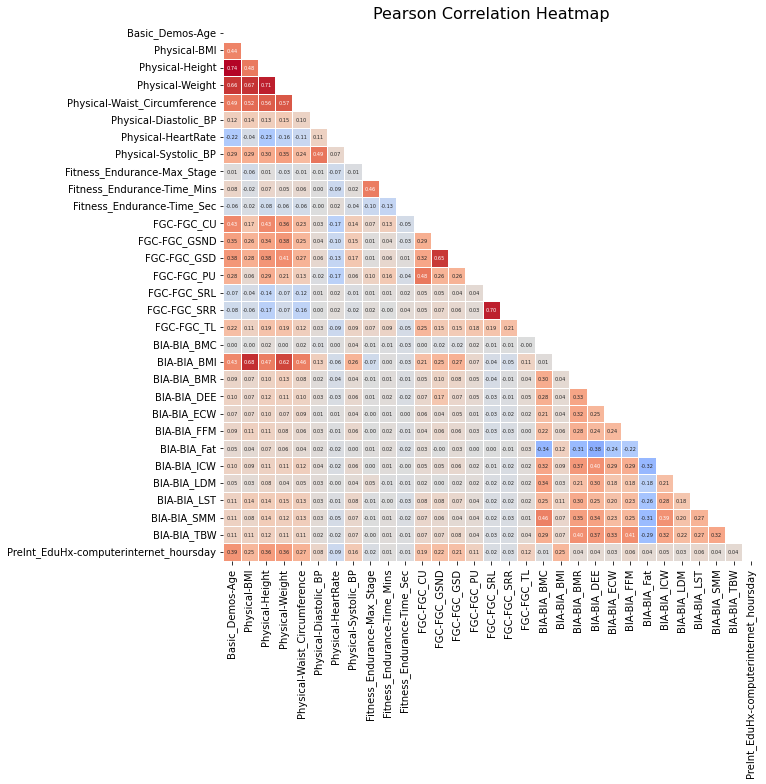

In [213]:

# column selection
df_corr = df[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

# TRAIN DATASET 

In [214]:
df_train= df[['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM',
       'BIA-BIA_TBW', 'PAQ_A-Season', 'PAQ_A-PAQ_A_Total', 'PAQ_C-Season',
       'PAQ_C-PAQ_C_Total', 'PCIAT-Season', 'PCIAT-PCIAT_01', 'PCIAT-PCIAT_02',
       'PCIAT-PCIAT_03', 'PCIAT-PCIAT_04', 'PCIAT-PCIAT_05', 'PCIAT-PCIAT_06',
       'PCIAT-PCIAT_07', 'PCIAT-PCIAT_08', 'PCIAT-PCIAT_09', 'PCIAT-PCIAT_10',
       'PCIAT-PCIAT_11', 'PCIAT-PCIAT_12', 'PCIAT-PCIAT_13', 'PCIAT-PCIAT_14',
       'PCIAT-PCIAT_15', 'PCIAT-PCIAT_16', 'PCIAT-PCIAT_17', 'PCIAT-PCIAT_18',
       'PCIAT-PCIAT_19', 'PCIAT-PCIAT_20', 'PCIAT-PCIAT_Total', 'SDS-Season',
       'SDS-SDS_Total_Raw', 'SDS-SDS_Total_T', 'PreInt_EduHx-Season',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-BMI_CAL',
        'BIA-BIA_TBW_CAL', 'BIA-BIA_LST_CAL']].copy()

In [215]:
df_train=df_train[(round(df_train['Physical-BMI_CAL'],0)==round(df_train['Physical-BMI'],0)) 
         & (round(df_train['Physical-BMI_CAL'],0)==round(df_train['BIA-BIA_BMI'],0)) 
         & (round(df_train['BIA-BIA_TBW'],0)==round(df_train['BIA-BIA_TBW_CAL'],0))
         & (round(df_train['BIA-BIA_LST_CAL'],0)==round(df_train['BIA-BIA_LST'],0))
         & (df_train["BIA-BIA_FFM"] < df_train["Physical-Weight"])]

df_train

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii,Physical-BMI_CAL,BIA-BIA_TBW_CAL,BIA-BIA_LST_CAL
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.00,50.8,...,55.0,NaN,NaN,NaN,Fall,3.0,2.0,16.877316,32.69088,38.91765
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.00,46.0,...,0.0,Fall,46.0,64.0,Summer,0.0,0.0,14.035590,27.05513,39.44961
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,...,44.0,Summer,31.0,45.0,Winter,0.0,1.0,18.292347,45.99660,58.93379
6,6,Fall,10,0,Spring,NaN,Fall,19.660760,55.00,84.6,...,20.0,Winter,27.0,40.0,Fall,3.0,0.0,19.660760,47.22110,59.46429
7,7,Fall,10,1,NaN,65.0,Fall,16.861286,59.25,84.2,...,NaN,Spring,39.0,55.0,Fall,2.0,0.0,16.861286,50.47670,63.89544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3952,3952,Summer,15,0,Spring,40.0,Winter,26.364710,70.50,186.4,...,NaN,Spring,66.0,90.0,Summer,3.0,1.0,26.364710,91.48870,118.43319
3953,3953,Fall,8,0,Spring,65.0,Fall,17.139810,52.50,67.2,...,22.0,Fall,41.0,58.0,Fall,2.0,0.0,17.139810,36.71810,49.33007
3954,3954,Summer,7,1,NaN,NaN,Summer,13.927006,48.50,46.6,...,33.0,Summer,48.0,67.0,Summer,0.0,1.0,13.927006,30.04522,42.81850
3955,3955,Fall,13,0,Spring,60.0,Fall,16.362460,59.50,82.4,...,32.0,Winter,35.0,50.0,Fall,1.0,1.0,16.362460,52.83200,66.28893


In [216]:
df_train.describe()

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,...,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-BMI_CAL,BIA-BIA_TBW_CAL,BIA-BIA_LST_CAL
count,1841.000000,1841.000000,1841.000000,1666.000000,1841.000000,1841.000000,1841.000000,1188.000000,1826.000000,1833.000000,...,1659.000000,1659.000000,1659.000000,1583.000000,1583.000000,1813.000000,1841.000000,1841.000000,1841.000000,1841.000000
mean,1980.900598,10.378599,0.367192,64.679472,19.403495,56.011266,91.203064,26.429082,68.967141,81.678123,...,1.137432,0.913803,27.328511,41.077069,57.751105,1.058467,0.529603,19.403454,50.155898,63.771689
std,1131.514025,3.499621,0.482170,11.078829,4.992032,7.319750,43.174174,3.648041,13.304691,13.335814,...,1.336295,1.159394,20.229085,10.346176,13.155828,1.067739,0.759232,4.992027,19.371179,25.333783
min,0.000000,5.000000,0.000000,30.000000,11.925153,40.500000,33.200000,19.000000,0.000000,33.000000,...,0.000000,0.000000,0.000000,25.000000,38.000000,0.000000,0.000000,11.925153,21.617290,23.620150
25%,1011.000000,8.000000,0.000000,60.000000,15.954323,50.500000,58.800000,26.000000,61.000000,73.000000,...,0.000000,0.000000,11.000000,34.000000,49.000000,0.000000,0.000000,15.954323,35.950600,45.349270
50%,1983.000000,10.000000,0.000000,65.000000,17.972983,55.000000,78.800000,26.000000,67.000000,81.000000,...,1.000000,1.000000,26.000000,39.000000,55.000000,1.000000,0.000000,17.972983,44.819900,56.883110
75%,2953.000000,13.000000,1.000000,71.000000,21.441500,62.000000,113.600000,26.000000,75.000000,90.000000,...,2.000000,1.000000,40.000000,46.000000,64.000000,2.000000,1.000000,21.441500,60.000700,76.286930
max,3957.000000,22.000000,1.000000,95.000000,53.918413,78.500000,315.000000,50.000000,179.000000,138.000000,...,5.000000,5.000000,93.000000,85.000000,100.000000,3.000000,3.000000,53.918413,143.762100,198.353050


In [217]:
df_train[["BIA-BIA_SMM", "BIA-BIA_FFM"]][df_train["BIA-BIA_SMM"] > df_train["BIA-BIA_FFM"]]

,BIA-BIA_SMM,BIA-BIA_FFM


In [218]:
df_train[["Physical-Weight", "BIA-BIA_FFM"]][(df_train["BIA-BIA_FFM"] > df_train["Physical-Weight"]) & (df_train["Physical-Weight"] > 0) ]

,Physical-Weight,BIA-BIA_FFM


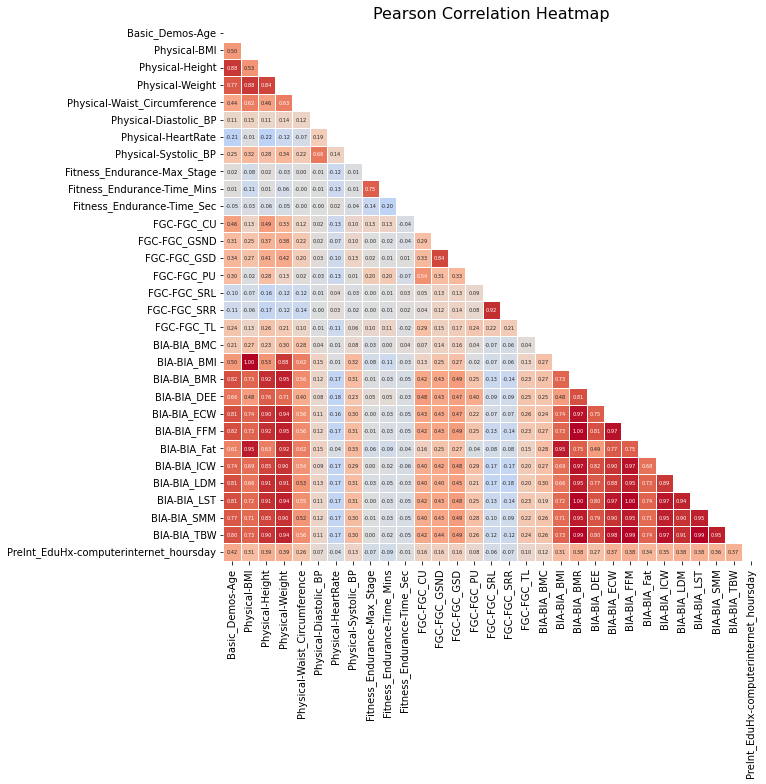

In [219]:

# column selection
df_corr = df_train[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

## Train df with a margin of acceptance (delta)

In [231]:
df_train_margin=df.copy()

In [229]:
df_train_margin=df_train_margin[
    (df_train_margin['Physical-BMI_DELTA']<=0.4)
    & (df_train_margin['BIA-BIA_TBW_DELTA']<=0.4)
    & (df_train_margin['BIA-BIA_LST_DELTA']<=0.4)
    & (df_train_margin["BIA-BIA_FFM"] < df_train_margin["Physical-Weight"])]
df_train_margin

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,Physical-BMI_DELTA,BIA-BIA_FFM_CAL,BIA-BIA_TBW_CAL,BIA-BIA_TBW_DELTA,BIA-BIA_LST_CAL,BIA-BIA_LST_DELTA,BIA-BIA_LDM_CAL,BIA-BIA_LDM_CAL2,BIA-BIA_DEE_CAL,Fat_mass
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,...,1.890399e-11,44.659699,32.69088,2.000000e-05,38.91765,0.00005,8.8953,6.22677,1864.996,6477.985880
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,...,2.222222e-09,36.960656,27.05513,7.000000e-05,39.44961,0.00009,14.9739,12.39448,1873.312,2791.802880
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,...,1.224493e-09,62.836885,45.99660,0.000000e+00,58.93379,0.00001,16.7791,12.93719,3394.290,13234.954880
5,5,Spring,13,1,Winter,50.0,Summer,22.279952,59.5,112.2,...,7.923191e-10,86.238388,63.12650,7.105427e-15,79.69814,0.00006,20.9020,16.57164,2661.940,47789.126700
6,6,Fall,10,0,Spring,NaN,Fall,19.660760,55.0,84.6,...,5.785132e-10,64.509699,47.22110,0.000000e+00,59.46429,0.00001,16.0259,12.24319,2271.720,15012.802750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3952,3952,Summer,15,0,Spring,40.0,Winter,26.364710,70.5,186.4,...,4.646648e-09,124.984563,91.48870,0.000000e+00,118.43319,0.00019,33.9033,26.94449,5157.930,42893.356905
3953,3953,Fall,8,0,Spring,65.0,Fall,17.139810,52.5,67.2,...,3.809525e-09,50.161339,36.71810,0.000000e+00,49.33007,0.00003,15.8150,12.61197,3105.810,10311.958125
3954,3954,Summer,7,1,NaN,NaN,Summer,13.927006,48.5,46.6,...,1.970454e-09,41.045492,30.04522,8.000000e-05,42.81850,0.00000,15.1400,12.77328,966.287,974.450142
3955,3955,Fall,13,0,Spring,60.0,Fall,16.362460,59.5,82.4,...,1.771060e-09,72.174863,52.83200,7.105427e-15,66.28893,0.00003,17.9797,13.45693,3620.640,8147.460545


In [232]:
df_train_margin=df_train_margin[
    (df_train_margin['Physical-BMI_DELTA']<=10)
    & (df_train_margin['BIA-BIA_TBW_DELTA']<=90)
    & (df_train_margin['BIA-BIA_LST_DELTA']<=180)
    & (df_train_margin["BIA-BIA_FFM"] < df_train_margin["Physical-Weight"])]
df_train_margin

,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,...,Physical-BMI_DELTA,BIA-BIA_FFM_CAL,BIA-BIA_TBW_CAL,BIA-BIA_TBW_DELTA,BIA-BIA_LST_CAL,BIA-BIA_LST_DELTA,BIA-BIA_LDM_CAL,BIA-BIA_LDM_CAL2,BIA-BIA_DEE_CAL,Fat_mass
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.00,50.8,...,1.890399e-11,44.659699,32.690880,2.000000e-05,38.917650,0.000050,8.895300,6.226770,1864.996000,6477.985880
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.00,46.0,...,2.222222e-09,36.960656,27.055130,7.000000e-05,39.449610,0.000090,14.973900,12.394480,1873.312000,2791.802880
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.00,81.6,...,1.224493e-09,62.836885,45.996600,0.000000e+00,58.933790,0.000010,16.779100,12.937190,3394.290000,13234.954880
5,5,Spring,13,1,Winter,50.0,Summer,22.279952,59.50,112.2,...,7.923191e-10,86.238388,63.126500,7.105427e-15,79.698140,0.000060,20.902000,16.571640,2661.940000,47789.126700
6,6,Fall,10,0,Spring,NaN,Fall,19.660760,55.00,84.6,...,5.785132e-10,64.509699,47.221100,0.000000e+00,59.464290,0.000010,16.025900,12.243190,2271.720000,15012.802750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8426,8426,Fall,7,0,Winter,77.0,Fall,18.020412,64.24,72.4,...,5.687012e+00,55.587936,44.893446,4.203077e+00,51.121736,9.092650,16.696690,6.228290,2178.221633,36454.241664
8427,8427,Summer,13,0,NaN,61.0,Summer,17.678204,61.22,96.9,...,4.975505e-01,59.548599,59.515784,1.592621e+01,65.878086,6.721269,26.681395,6.362301,4002.194734,NaN
8440,8440,Summer,10,1,Winter,59.5,Fall,17.322879,55.10,72.0,...,6.509967e-01,56.167508,41.374361,2.597455e-01,54.080156,6.436603,17.905819,12.705795,4652.546409,11454.499282
8451,8451,Winter,14,0,Fall,60.5,Fall,22.291181,66.27,123.8,...,2.473993e+00,77.854366,75.378904,1.838951e+01,87.157381,1.066397,36.850619,11.778477,2788.363108,39044.256123


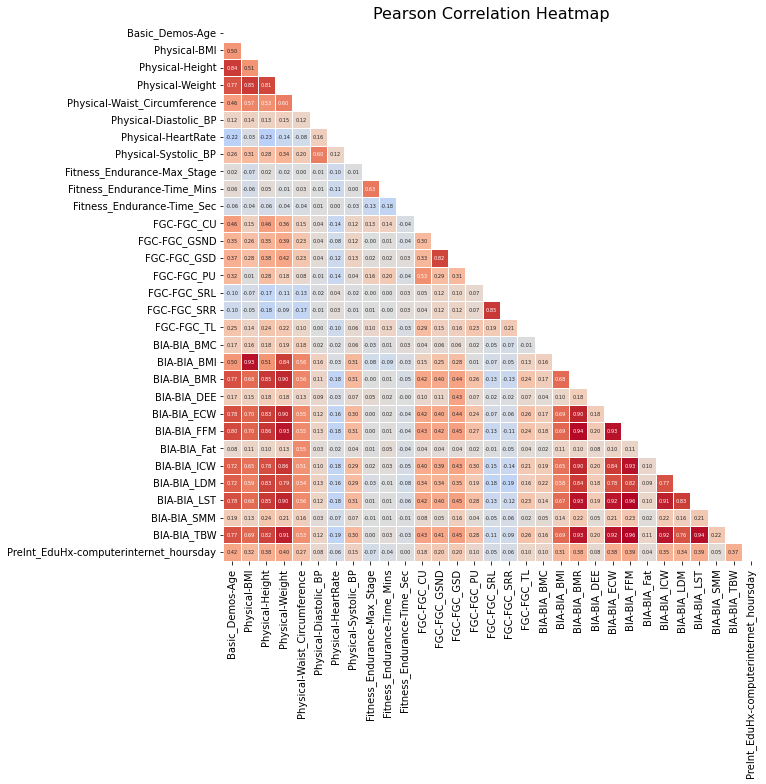

In [233]:
# column selection
df_corr = df_train_margin[cols]
 
# Pearson correlation
corr = df_corr.corr(method='pearson')
 
mask = np.triu(np.ones_like(corr, dtype=bool))
 
# heatmap
plt.figure(figsize=(11, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,             
    fmt=".2f",              
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar=False,
    annot_kws={"size": 5},   
    cbar_kws={"shrink": 0.8}
)
 
plt.title("Pearson Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

In [224]:
df.to_csv("../1.DATASET/df_CAL_vars.csv", index=False)